# Vegetation Data Access

Accessing NDVI data

# STEP 2: AppEEARS API

# STEP 0: Set up

To get started on this notebook, you’ll need to restore any variables
from previous notebooks to your workspace. To save time and memory, make
sure to specify which variables you want to load.

In [24]:
%store -r

You will also need to import any libraries you are using in this
notebook, since they won’t carry over from the previous notebook:

In [21]:
# Import libraries
import json
import os
import pathlib
import shutil
from glob import glob

import earthpy.api.appeears as eaapp
import earthpy
import geopandas as gpd
import hvplot.pandas 
import hvplot.xarray
import pandas as pd
import rioxarray as rxr
import xarray as xr

import holoviews as hv

In [3]:
# Initialize AppeearsDownloader for MODIS NDVI data
ndvi_downloader = eaapp.AppeearsDownloader(
    download_key=download_key,
    ea_dir=project.project_dir,
    product='MOD13Q1.061',
    layer='_250m_16_days_NDVI',
    start_date="01-01",
    end_date="01-31",
    recurring=True,
    year_range=[, ],
    polygon=gdf
)
# Download the prepared download -- this can take some time!
ndvi_downloader.download_files(cache=True)

In [ ]:
# Poudre
# Initialize AppeearsDownloader for MODIS NDVI data
ndvi_downloader = eaapp.AppeearsDownloader(
    download_key='poudre-ndvi',
    # ea_dir=project.project_dir,
    product='MOD13Q1.061',
    layer='_250m_16_days_NDVI',
    # 250 m resolution, collected every 16 days
    start_date="05-01",
    end_date="08-01",
    recurring=True,
    year_range=[2018,2022],
    polygon=poudre_gdf
)
# Download the prepared download -- this can take some time!
ndvi_downloader.download_files(cache=True)


**Final Configuration Loaded:**
{}
Found 'data_home' in environment variables.


<generator object Path.rglob at 0x7b00137c7de0>

In [28]:
# Vicente
# Initialize AppeearsDownloader for MODIS NDVI data
ndvi_downloader2 = eaapp.AppeearsDownloader(
    download_key='vicente-ndvi',
    # ea_dir=project.project_dir,
    product='MOD13Q1.061',
    layer='_250m_16_days_NDVI',
    # 250 m resolution, collected every 16 days
    start_date="05-01",
    end_date="08-01",
    recurring=True,
    year_range=[2018,2022],
    polygon=vicente_gdf
)
# Download the prepared download -- this can take some time!
ndvi_downloader2.download_files(cache=True)


**Final Configuration Loaded:**
{}
Found 'data_home' in environment variables.
No stored credentials found for urs.earthdata.nasa.gov. Please log in.


/opt/conda/lib/python3.11/site-packages/earthpy/api/auth.py:192: UserWarning: Setting credentials not supported for 'netrc' backend.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/earthpy/api/auth.py:196: UserWarning: Failed to store credentials with 'keyring': No recommended backend was available. Install a recommended 3rd party backend package; or, install the keyrings.alt package if you want to use the non-recommended backends. See https://pypi.org/project/keyring for details.
  warnings.warn(


Credentials stored using 'env' backend.


In [29]:
ndvi_downloader2.download_dir

PosixPath('/workspaces/data/earthpy-downloads/vicente-ndvi')

In [ ]:
# poudre
# Get a sorted list of NDVI tif file paths
ndvi_paths = sorted(list(ndvi_downloader.download_dir.rglob('*NDVI*.tif')))

# Display the first and last three files paths to check the pattern
ndvi_paths[:3], ndvi_paths[-3:]

([PosixPath('/workspaces/data/earthpy-downloads/poudre-ndvi/MOD13Q1.061_2018106_to_2022213/MOD13Q1.061__250m_16_days_NDVI_doy2018113000000_aid0001.tif'),
  PosixPath('/workspaces/data/earthpy-downloads/poudre-ndvi/MOD13Q1.061_2018106_to_2022213/MOD13Q1.061__250m_16_days_NDVI_doy2018129000000_aid0001.tif'),
  PosixPath('/workspaces/data/earthpy-downloads/poudre-ndvi/MOD13Q1.061_2018106_to_2022213/MOD13Q1.061__250m_16_days_NDVI_doy2018145000000_aid0001.tif')],
 [PosixPath('/workspaces/data/earthpy-downloads/poudre-ndvi/MOD13Q1.061_2018106_to_2022213/MOD13Q1.061__250m_16_days_NDVI_doy2022177000000_aid0001.tif'),
  PosixPath('/workspaces/data/earthpy-downloads/poudre-ndvi/MOD13Q1.061_2018106_to_2022213/MOD13Q1.061__250m_16_days_NDVI_doy2022193000000_aid0001.tif'),
  PosixPath('/workspaces/data/earthpy-downloads/poudre-ndvi/MOD13Q1.061_2018106_to_2022213/MOD13Q1.061__250m_16_days_NDVI_doy2022209000000_aid0001.tif')])

In [ ]:
# vicente
# Get a sorted list of NDVI tif file paths
ndvi_paths2 = sorted(list(ndvi_downloader2.download_dir.rglob('*NDVI*.tif')))

# Display the first and last three files paths to check the pattern
ndvi_paths2[:3], ndvi_paths2[-3:]

([PosixPath('/workspaces/data/earthpy-downloads/vicente-ndvi/MOD13Q1.061_2018106_to_2022213/MOD13Q1.061__250m_16_days_NDVI_doy2018113000000_aid0001.tif'),
  PosixPath('/workspaces/data/earthpy-downloads/vicente-ndvi/MOD13Q1.061_2018106_to_2022213/MOD13Q1.061__250m_16_days_NDVI_doy2018129000000_aid0001.tif'),
  PosixPath('/workspaces/data/earthpy-downloads/vicente-ndvi/MOD13Q1.061_2018106_to_2022213/MOD13Q1.061__250m_16_days_NDVI_doy2018145000000_aid0001.tif')],
 [PosixPath('/workspaces/data/earthpy-downloads/vicente-ndvi/MOD13Q1.061_2018106_to_2022213/MOD13Q1.061__250m_16_days_NDVI_doy2022177000000_aid0001.tif'),
  PosixPath('/workspaces/data/earthpy-downloads/vicente-ndvi/MOD13Q1.061_2018106_to_2022213/MOD13Q1.061__250m_16_days_NDVI_doy2022193000000_aid0001.tif'),
  PosixPath('/workspaces/data/earthpy-downloads/vicente-ndvi/MOD13Q1.061_2018106_to_2022213/MOD13Q1.061__250m_16_days_NDVI_doy2022209000000_aid0001.tif')])

In [ ]:
# poudre
doy_start = -25
doy_end = -18

# Loop through each NDVI image
ndvi_poudre = []
for ndvi_path in ndvi_paths:
    # Get date from file name
    date = pd.to_datetime(ndvi_path.name[doy_start:doy_end], format = '%Y%j')
    # Open dataset
    # use mask_and_scale to keep the full data format
    # use .squeeze to get rid of any dimensions that have only 1 value
    da = rxr.open_rasterio(ndvi_path, mask_and_scale = True).squeeze()
    # da.plot()
    
    # Add date dimension and clean up metadata
    da = da.assign_coords({'date': date})
    da = da.expand_dims({'date': 1})
    da.name = 'NDVI'

    # Prepare for concatenation
    ndvi_poudre.append(da)

len(ndvi_poudre)

35

In [31]:
# vicente
doy_start = -25
doy_end = -18

# Loop through each NDVI image
ndvi_vicente = []
for ndvi_path in ndvi_paths2:
    # Get date from file name
    date = pd.to_datetime(ndvi_path.name[doy_start:doy_end], format = '%Y%j')
    # Open dataset
    # use mask_and_scale to keep the full data format
    # use .squeeze to get rid of any dimensions that have only 1 value
    da = rxr.open_rasterio(ndvi_path, mask_and_scale = True).squeeze()
    # da.plot()
    
    # Add date dimension and clean up metadata
    da = da.assign_coords({'date': date})
    da = da.expand_dims({'date': 1})
    da.name = 'NDVI'

    # Prepare for concatenation
    ndvi_vicente.append(da)

len(ndvi_vicente)

35

In [ ]:
# poudre
# Combine NDVI images from all dates
annual_ndvi_poudre = (
    xr.combine_by_coords(ndvi_poudre)
    .resample(dict(date = 'YS')) # resapmle for annual 
    .mean())

annual_ndvi_poudre

<xarray.Dataset> Size: 45kB
Dimensions:      (date: 5, y: 33, x: 67)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 536B -105.5 -105.5 -105.5 ... -105.4 -105.4 -105.4
  * y            (y) float64 264B 40.69 40.69 40.69 40.69 ... 40.63 40.63 40.63
    spatial_ref  int64 8B 0
  * date         (date) datetime64[ns] 40B 2018-01-01 2019-01-01 ... 2022-01-01
Data variables:
    NDVI         (date, y, x) float32 44kB 0.5253 0.4979 ... 0.4571 0.4304

In [32]:
# vicente
# Combine NDVI images from all dates
annual_ndvi_vicente = (
    xr.combine_by_coords(ndvi_vicente)
    .resample(dict(date = 'YS')) # resapmle for annual 
    .mean())

annual_ndvi_vicente

<xarray.Dataset> Size: 169kB
Dimensions:      (date: 5, y: 91, x: 92)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 736B -122.3 -122.3 -122.3 ... -122.1 -122.1 -122.1
  * y            (y) float64 728B 37.14 37.14 37.13 37.13 ... 36.96 36.95 36.95
    spatial_ref  int64 8B 0
  * date         (date) datetime64[ns] 40B 2018-01-01 2019-01-01 ... 2022-01-01
Data variables:
    NDVI         (date, y, x) float32 167kB 0.865 0.865 0.8674 ... 0.2945 0.3883

In [ ]:
# poudre
# Combine NDVI images from all dates
da = xr.combine_by_coords(ndvi_poudre, coords=['date'])
da

<xarray.Dataset> Size: 311kB
Dimensions:      (date: 35, y: 33, x: 67)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 536B -105.5 -105.5 -105.5 ... -105.4 -105.4 -105.4
  * y            (y) float64 264B 40.69 40.69 40.69 40.69 ... 40.63 40.63 40.63
    spatial_ref  int64 8B 0
  * date         (date) datetime64[ns] 280B 2018-04-23 2018-05-09 ... 2022-07-28
Data variables:
    NDVI         (date, y, x) float32 310kB 0.4295 0.4363 ... 0.5121 0.4485

In [33]:
# vicente
# Combine NDVI images from all dates
da_v = xr.combine_by_coords(ndvi_vicente, coords=['date'])
da_v

<xarray.Dataset> Size: 1MB
Dimensions:      (date: 35, y: 91, x: 92)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 736B -122.3 -122.3 -122.3 ... -122.1 -122.1 -122.1
  * y            (y) float64 728B 37.14 37.14 37.13 37.13 ... 36.96 36.95 36.95
    spatial_ref  int64 8B 0
  * date         (date) datetime64[ns] 280B 2018-04-23 2018-05-09 ... 2022-07-28
Data variables:
    NDVI         (date, y, x) float32 1MB 0.8503 0.8503 0.846 ... nan nan nan

In [35]:
# select data from before 
pre_ndvi_poudre = (
    da # call out var
    .sel(date = slice('2018','2019')) # select data
    .mean(dim = 'date')
    .NDVI
)
pre_ndvi_poudre.plot()

AttributeError: 'DataArray' object has no attribute 'NDVI'

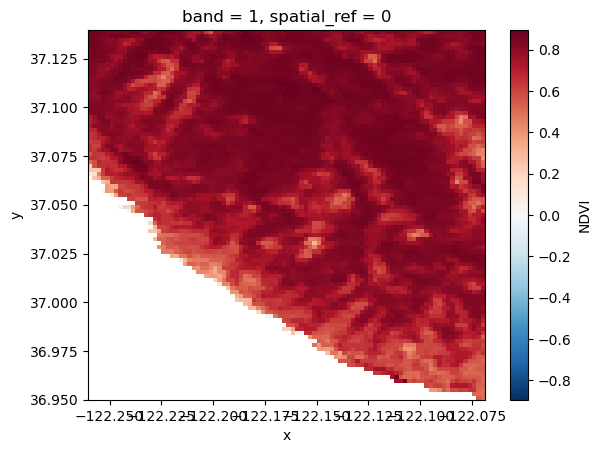

In [36]:
# select data from before 
pre_ndvi_vicente = (
    da_v # call out var
    .sel(date = slice('2018','2019')) # select data
    .mean(dim = 'date')
    .NDVI
)
pre_ndvi_vicente.plot()

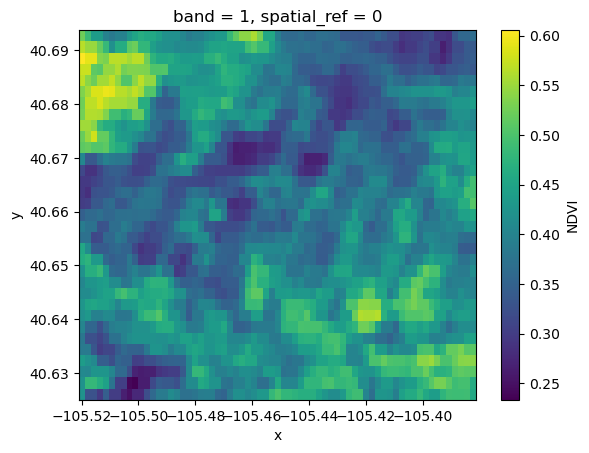

In [18]:
# select data from after 
post_ndvi_poudre = (
    da # call out var
    .sel(date = slice('2021','2022')) # select data
    .mean(dim = 'date')
    .NDVI
)
post_ndvi_poudre.plot()

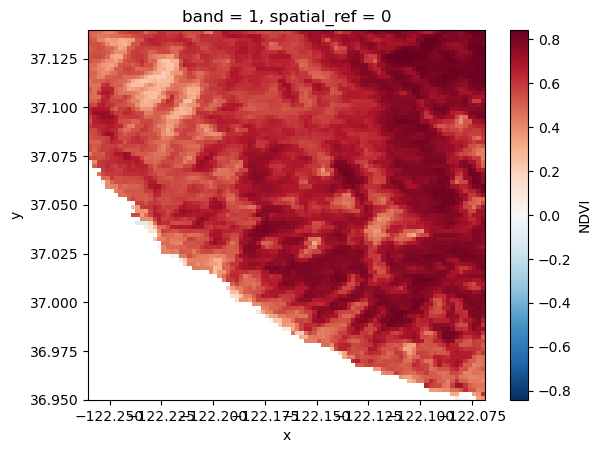

In [37]:
# select data from after 
post_ndvi_vicente = (
    da_v # call out var
    .sel(date = slice('2021','2022')) # select data
    .mean(dim = 'date')
    .NDVI
)
post_ndvi_vicente.plot()

In [23]:
# Compute the difference in NDVI before and after
ndvi_diff_poudre = post_ndvi_poudre - pre_ndvi_poudre
# Plot the difference
ndvi_diff_poudre_plot = (
    ndvi_diff_poudre.hvplot(x='x', y='y', cmap='PiYG', geo=True, 
                     title = 'Difference in NDVI before and after Cameron Peak Fire in the Poudre Wilderness')
    *
    poudre_gdf.hvplot(geo=True, fill_color=None, line_color='black')
)
hv.save(ndvi_diff_poudre_plot, 'ndvi_diff_poudre_plot.html')
ndvi_diff_poudre_plot

:Overlay
   .Image.I    :Image   [x,y]   (NDVI)
   .Polygons.I :Polygons   [Longitude,Latitude]

In [ ]:
# Compute the difference in NDVI before and after
ndvi_diff_vicente = post_ndvi_vicente - pre_ndvi_vicente
# Plot the difference
ndvi_diff_vicente_plot = (
    ndvi_diff_vicente.hvplot(x='x', y='y', cmap='PiYG', geo=True, 
                     title = 'Difference in NDVI before and after 2020 CZU Fire in the San Vicente Redwoods')
    *
    vicente_gdf.hvplot(geo=True, fill_color=None, line_color='black')
)
hv.save(ndvi_diff_vicente_plot, 'ndvi_diff_vicente_plot.html')
ndvi_diff_vicente_plot

:Overlay
   .Image.I    :Image   [x,y]   (NDVI)
   .Polygons.I :Polygons   [Longitude,Latitude]

In [41]:
# Compute the difference in NDVI before and after
ndvi_diff_vicente = post_ndvi_vicente - pre_ndvi_vicente
# Plot the difference
ndvi_diff_vicente_plot2 = (
    ndvi_diff_vicente.hvplot(x='x', y='y', cmap='PiYG', geo=True, 
                     title = 'Difference in NDVI before and after\n 2020 CZU Fire in the San Vicente Redwoods')
    *
    vicente_gdf.hvplot(geo=True, fill_color=None, line_color='black')
)
hv.save(ndvi_diff_vicente_plot2, 'ndvi_diff_vicente_plot2.html')
ndvi_diff_vicente_plot2

:Overlay
   .Image.I    :Image   [x,y]   (NDVI)
   .Polygons.I :Polygons   [Longitude,Latitude]

# STEP -1: Wrap up

Don’t forget to store your variables so you can use them in other
notebooks! Replace `var1` and `var2` with the variable you want to save,
separated by spaces.

In [12]:
%store var1 var2

Finally, be sure to `Restart` and `Run all` to make sure your notebook
works all the way through!